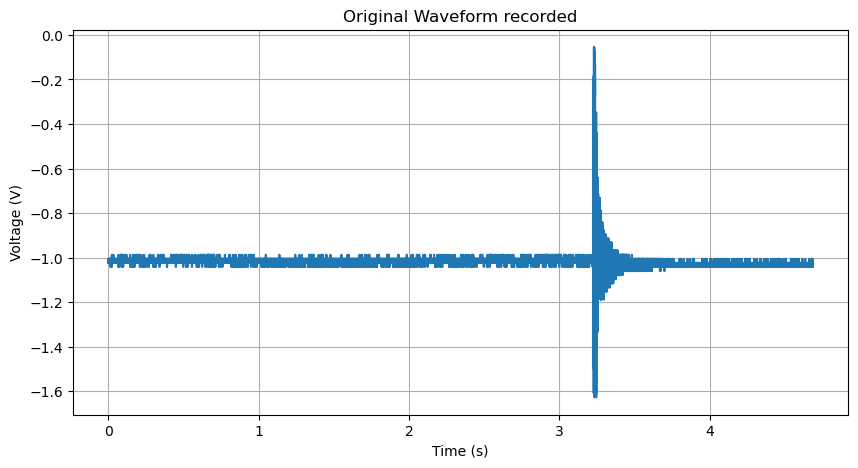

In [57]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# Load the CSV file
filepath = 'Waveforms/DATASET_02/TEST3_20_JULY_1533.csv'

# Load the data, skipping the second row which contains units
df = pd.read_csv(filepath, skiprows=[1])

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df.iloc[:, 0], df.iloc[:, 1])
plt.title("Original Waveform recorded")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

### What are we going to find?

We are trying to find the actual peak frequncy between bins `k-1` and `k+1`; where `y(k)` is the data set with the hgihest frequency.

Formula in use - 

$$
f_{true} = (k + \delta) \cdot \Delta f
$$

where $\delta$ is the fractional shift from the peak frequency.

$\delta$ is given by:

$$
    \delta = \frac{1}{2} \cdot \frac {ln(y_{k-1}) - ln(y_{k+1})}{ln(y_{k-1}) - 2ln(y_k) + ln(y_{k+1})}
$$

Number of samples: 3800
95.21006527736088
Frequency resolution: 5.263157894749108 Hz
Standard FFT Peak: 473.6842 Hz
Refined Fitted Peak: 473.8948 Hz


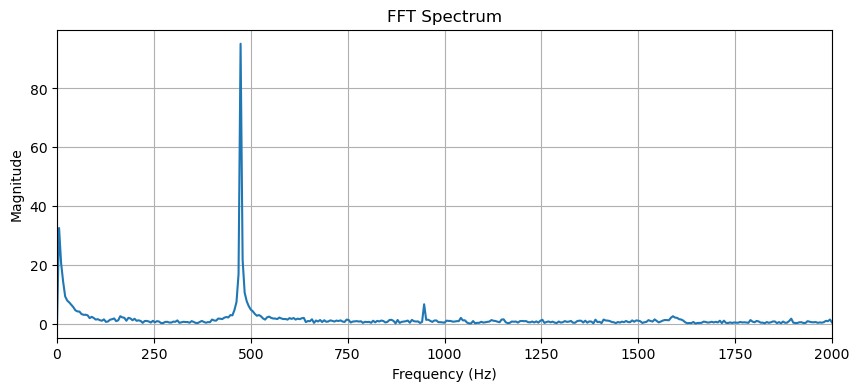

In [ ]:
# FFT analysis on waveform from time 3.25 to 3.45 seconds
df_fft = df[(df['Time'] >= 3.26) & (df['Time'] <= 3.45)]

dt = df_fft['Time'].iloc[1] - df_fft['Time'].iloc[0]
fs = 1.0 / dt

# cancelling offset
y = df_fft['Channel A'].values - np.mean(df_fft['Channel A'].values)

# Performing FFT
n = len(y)
print(f"Number of samples: {n}")
yf = np.fft.rfft(y)
xf = np.fft.rfftfreq(n, d=dt)

# Get peak frequency y(k)
peak_idx = np.argmax(np.abs(yf))

y_k   = np.abs(yf[peak_idx])
y_km1 = np.abs(yf[peak_idx - 1])  # Left bin
y_kp1 = np.abs(yf[peak_idx + 1])  # Right bin

df = xf[1] - xf[0]
print(f"Frequency resolution: {df} Hz")

l_km1 = np.log(y_km1)
l_k   = np.log(y_k)
l_kp1 = np.log(y_kp1)

delta = 0.5 * (l_km1 - l_kp1) / (l_km1 - 2 * l_k + l_kp1)
refined_peak_freq = (peak_idx + delta) * df

print(f"Standard FFT Peak: {xf[peak_idx]:.4f} Hz")
print(f"Refined Fitted Peak: {refined_peak_freq:.4f} Hz")

# Plotting the FFT spectrum 
plt.figure(figsize=(10, 4))
plt.plot(xf, np.abs(yf))
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)
plt.grid(True)
plt.show()

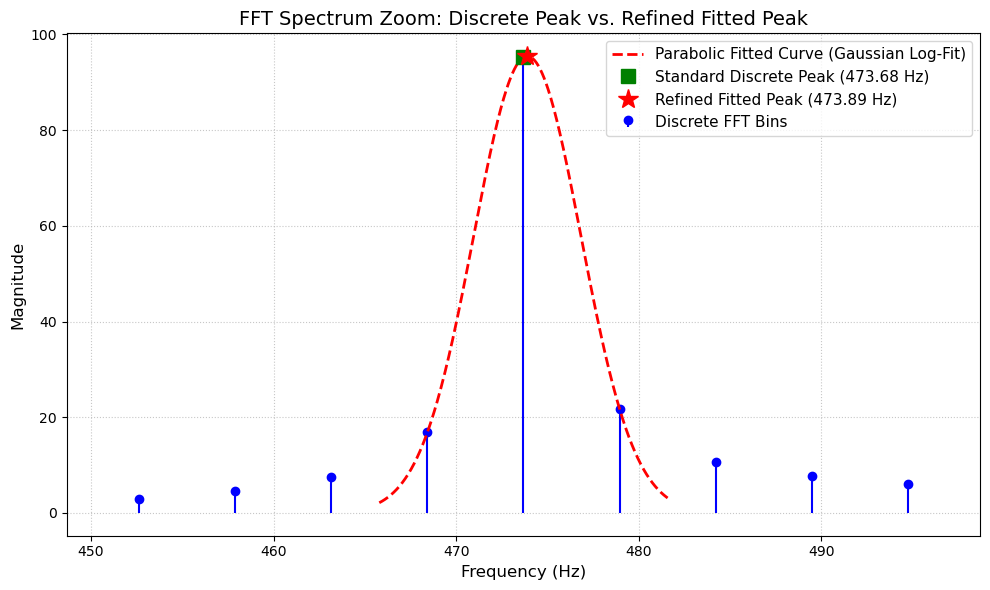

In [59]:
df_bin = xf[1] - xf[0]
standard_peak_freq = xf[peak_idx]
delta_fine = np.linspace(-1.5, 1.5, 300)
freq_fine = (peak_idx + delta_fine) * df_bin

a = 0.5 * (l_km1 - 2 * l_k + l_kp1)
b = 0.5 * (l_kp1 - l_km1)
c = l_k

log_magnitude_fine = a * (delta_fine**2) + b * delta_fine + c
magnitude_fine = np.exp(log_magnitude_fine)
refined_mag = np.exp(c - (b**2)/(4*a))

# 8. Plotting
plt.figure(figsize=(10, 6))

# Discrete bins around the peak
neighbor_indices = range(peak_idx - 8, peak_idx + 9)
plt.stem(xf[neighbor_indices], np.abs(yf[neighbor_indices]), 
         linefmt='b-', markerfmt='bo', basefmt=" ", label='Discrete FFT Bins')

# Fitted curve
plt.plot(freq_fine, magnitude_fine, 'r--', linewidth=2, label='Parabolic Fitted Curve (Gaussian Log-Fit)')

# Markers
plt.plot(standard_peak_freq, y_k, 'gs', markersize=10, label=f'Standard Discrete Peak ({standard_peak_freq:.2f} Hz)')
plt.plot(refined_peak_freq, refined_mag, 'r*', markersize=15, label=f'Refined Fitted Peak ({refined_peak_freq:.2f} Hz)')

plt.title("FFT Spectrum Zoom: Discrete Peak vs. Refined Fitted Peak", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Magnitude", fontsize=12)
plt.xlim(standard_peak_freq - 25, standard_peak_freq + 25)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()